# Weak Scaling - Container

Container SIDE + native comparison.

This experiment focus on the weak scaling.\
We fix $N/P$, vary $P$. Per-process work stays constant in the local sort phase; per-process communicated volume grows as $N(P-1)/P \to N$. So weak scaling is inherently bad at high $P$ — show this and discuss whether a different sort (e.g. histogram sort or hyperquicksort) would do better and why.

The experiment focus mostly on **MPI** level (since **k** literally is the number of MPI ranks). The number of **OMP threads** are fixed to 4. $N$ varies at each iteration.\
In particular $N/P = 2 \times 10^7$.

* **n_bits** : $64$
* **n_threads** : $4$
* **keys_distribution** : uniform
* **sorting_strategy** : radix
* **merging_strategy** : bin

Experiments were executed on [**Orfeo, partition GENOA**](https://orfeo-doc.areasciencepark.it/HPC/computational-resources/).

The key metrics here are **time_comunication_seconds** and **total_seconds**.

In [4]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [11]:
native_results = pd.read_csv("../parallel/results/weak_scaling.csv")
native_results = native_results[
    ["n_key","n_ranks", "distribution", "time_communication_seconds", "time_total_seconds", "time_merge_seconds", "time_sort_seconds"]
]
native_results["version"] = "native"
native_results.head()

KeyError: "['time_sort_seconds'] not in index"

In [6]:
container_results = pd.read_csv("../parallel/results/container_weak_scaling.csv")
container_results = container_results[
    ["n_key", "n_ranks", "distribution", "time_communication_seconds", "time_total_seconds"]
]
container_results["version"] = "container"
container_results.head()

,n_key,n_ranks,distribution,time_communication_seconds,time_total_seconds,version
0,80000000,4,uniform,0.428589,1.244623,container
1,160000000,8,uniform,0.505285,1.364903,container
2,320000000,16,uniform,0.907205,1.956920,container
3,640000000,32,uniform,1.619235,3.144439,container
4,80000000,4,uniform,0.429462,1.211566,container


In [7]:
results = pd.merge(native_results, container_results, "outer")

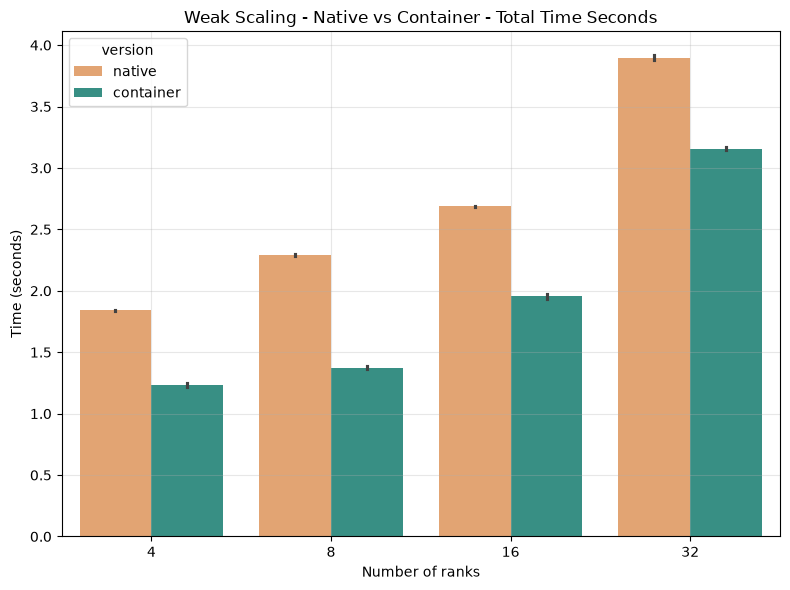

In [9]:
custom_palette = {
    "container": "#2a9d8f",
    "native": "#f4a261"
}

plt.figure(figsize=(8, 6))

sns.barplot(
    data=results,
    x="n_ranks",
    y="time_total_seconds",
    hue="version",
    palette=custom_palette,
    legend=True
)

plt.xlabel("Number of ranks")
plt.ylabel("Time (seconds)")
plt.title(f"Weak Scaling - Native vs Container - Total Time Seconds")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

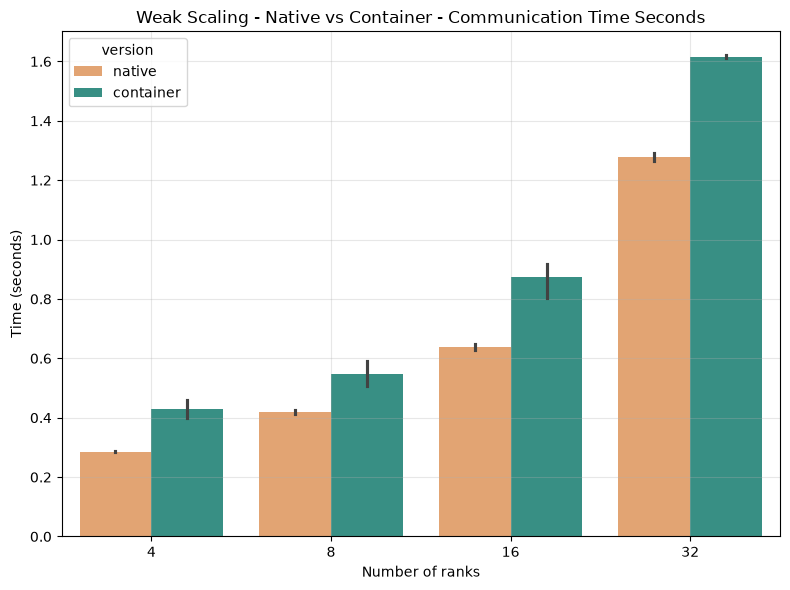

In [10]:
custom_palette = {
    "container": "#2a9d8f",
    "native": "#f4a261"
}

plt.figure(figsize=(8, 6))

sns.barplot(
    data=results,
    x="n_ranks",
    y="time_communication_seconds",
    hue="version",
    palette=custom_palette,
    legend=True
)

plt.xlabel("Number of ranks")
plt.ylabel("Time (seconds)")
plt.title(f"Weak Scaling - Native vs Container - Communication Time Seconds")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()